# Getting Started with TS-ICL — Forecasting

[![arXiv](https://img.shields.io/badge/arXiv-2606.05878-b31b1b.svg)](https://arxiv.org/abs/2606.05878) [![PyPI](https://img.shields.io/pypi/v/tsicl.svg)](https://pypi.org/project/tsicl)

> **TS-ICL** is a probabilistic **Time Series Foundation Model** (TSFM) that unifies **forecasting** and **imputation** in a single zero-shot architecture, requiring no task-specific training.

This notebook focuses on the **forecasting** use case: given a look-back window, TS-ICL predicts the next H timesteps with **probabilistic outputs**.

### What you will learn
0. [Load the TS-ICL checkpoint](#loading-the-model)
1. [Run zero-shot univariate forecasting](#univariate-forecasting)
2. [Run zero-shot univariate forecasting with partially observed look-back window](#univariate-partially-forecasting)
2. [Leverage exogenous covariates to sharpen forecasts](#covariate-forecasting)
3. [Leverage past-only exogenous covariates to sharpen forecasts](#past-covariate-forecasting)
4. [Interpret predictions — median, IQR bands, and empirical coverage](#output-format)
5. [Process multiple series efficiently via batch inference](#batch-processing)
6. [Tips & best practices](#tips-practices)

### Performance at a glance
On the `fev-bench` benchmark (100 univariate tasks, ~235k windows):
- **Within ~6% MASE** of Chronos-2 and **~3% of TiRex**
- **~40× faster** at inference than tabular foundation models — 15.4 ms per window on an H100 GPU
- Particularly **robust to missing look-back data**

<div align="center">
  <img src="../contents/fevbench.png" alt="TS-ICL architecture" width="75%" />
</div>

## Installation

In [ ]:
# Install the TS-ICL package (skip if already installed)
!pip install tsicl -q

## Imports

In [24]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from pathlib import Path

import sys, os 
sys.path.insert(0, os.path.join(os.getcwd(), "../"))

from tsicl.pipeline import TSICL
from tsicl.plot.forecasting import plot_sample_forecast

# Reproducibility
np.random.seed(42)
torch.manual_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch {torch.__version__}  |  device: {device}")

PyTorch 2.9.1  |  device: cpu


<a id="loading-the-model"></a>

## Loading the Model

The `tsicl-v1.ckpt` file contains two specialised TS-ICL checkpoints that share the same architecture but were trained on different tasks: one for imputation and the other for forecasting. You can find the checkpoint in the [TS-ICL Hugging Face repository](https://huggingface.co/taharnbl/TS-ICL/tree/main).

| Checkpoint | Training masking | Use case |
|---|---|---|
| **`imputation`** | Random pointwise + block masking, bidirectional context | Reconstruct missing values anywhere in the window |
| **`forecasting`** | Causal right-side masking only | Predict future values from a clean look-back |

Set `MODEL_PATH` to your downloaded checkpoint, or enable `allow_auto_download=True` for automatic fetching.

In [26]:
# ── Update this path to your local checkpoint ─────────────────────────────
MODEL_PATH = Path("../checkpoints/tsicl-v1.ckpt")

model = TSICL(
    model_path          = MODEL_PATH,
    allow_auto_download = False
)
print("✅  Model loaded")

✅  Model loaded


---
## Part 1 — Univariate and Covariate-Aware Forecasting

<details>
<summary><strong>Architecture in brief</strong> ▸</summary>

TS-ICL processes each time series through four successive modules:

1. **Time Series Encoder** `𝒮` — a Perceiver-style architecture that compresses the observed (timestamp, value) pairs into M = 32 learnable latent tokens via cross-attention. It accepts inputs of arbitrary length without any preprocessing.
2. **Channel Mixer** `𝓜` — aggregates information across channels via cross-attention. In the univariate case this is a simple self attention operation; when covariates are present, it selectively integrates their latent representations into the target’s representation.
3. **Temporal Context Query Module** `𝓅` — maps any query timestamp to a context-aware embedding using Fourier (NeRF-style) positional encoding + cross-attention. Querying at arbitrary timestamps is what makes the model naturally handle irregular grids.
4. **In-Context Regressor** `𝒫` — a causal Transformer that reads the observed (representation, value) pairs as “in-context training examples” and predicts quantiles at the future positions using causal self-attention.

<div align="center">
  <img src="../contents/TS-ICL-v1.png" alt="TS-ICL architecture" width="70%" />
</div>

</details>

### Key input convention

TS-ICL is designed to be highly flexible, supporting various time series structures and alignment conditions.

**(i) Supported Formats & Shapes**

We natively accept inputs as **NumPy arrays** or **Tensors** (e.g., PyTorch).

| Input Type | Supported Shapes | Description |
| :--- | :--- | :--- |
| **Context (`inputs`)** | `[L]` <br> `[N, L]` <br> `[N, L, 1]` | **L**: Context length (look-back), **N**: Batch size. |
| **Covariates (`covars`)** | `[L + H]` <br> `[N, L + H]` <br> `[N, L + H, K]` | **H**: Forecast horizon, **K**: Number of covariate features. Should cover context **and** horizon for full benefit. |

**(ii) Missing Data in the Look-back**
* **Partially Observed Context:** The context does **not** need to be fully observed — `NaN` values are handled natively by the encoder.

> ⚠️ **Note:** For covariates known only during the context (unknown during the horizon), pass `NaN` for unobserved covariate positions.

#### Use Case — Synthetic Dataset

We generate a 1 000-point signal using two **Gaussian Process** draws:
- **`daily_pattern`** — periodic at 24 h with a slow-varying envelope (ExpSineSquared × Matérn)
- **`weekly_pattern`** — periodic at 168 h with a slow-varying envelope (ExpSineSquared × Matérn)

The two components are added to form the target `signal`. Keeping them separate lets us later use `weekly_pattern` as a covariate — a clean analogue of real-world scenarios where a low-frequency exogenous driver (temperature, irradiance) is continuously observed.

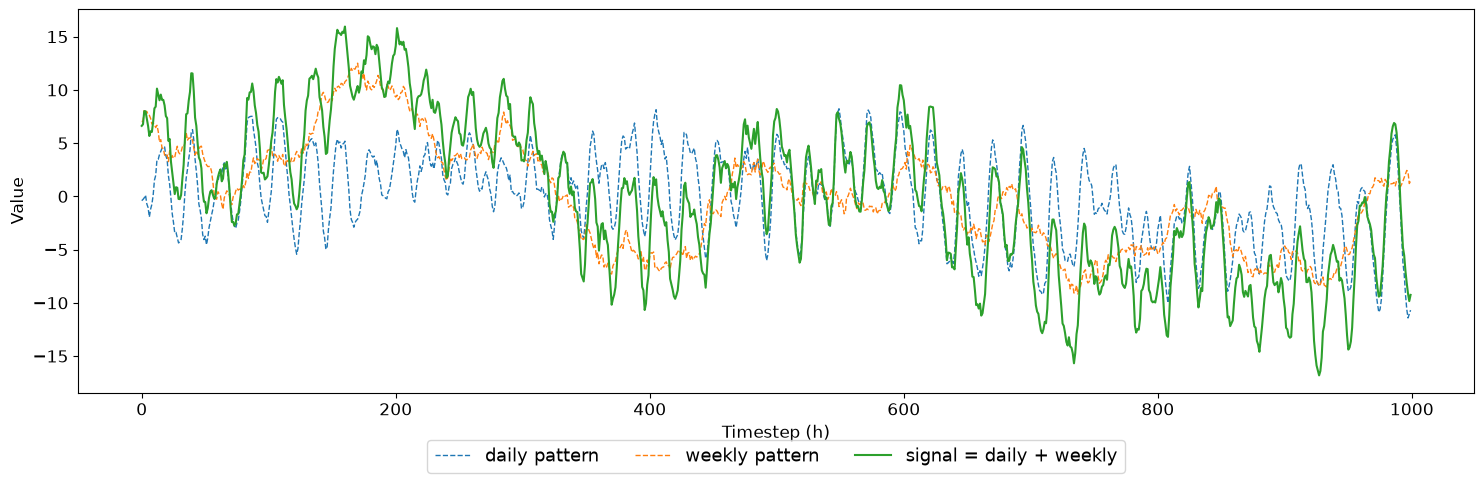

In [27]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ExpSineSquared, Matern

random_state = 91
np.random.seed(random_state)

T = 1000
t = np.arange(T, dtype=float).reshape(-1, 1)

# Daily pattern (period = 24 h)
kernel_daily  = ExpSineSquared(length_scale=1.5, periodicity=24.0) * Matern(length_scale=200.0, nu=0.5)
gp_daily      = GaussianProcessRegressor(kernel=kernel_daily, random_state=random_state)
daily_pattern = gp_daily.sample_y(t, random_state=random_state).flatten()
daily_pattern = 4.0 * (daily_pattern - daily_pattern.mean()) / daily_pattern.std()

# Weekly pattern (period = 168 h)
kernel_weekly  = ExpSineSquared(length_scale=3.0, periodicity=168.0) * Matern(length_scale=500.0, nu=0.5)
gp_weekly      = GaussianProcessRegressor(kernel=kernel_weekly, random_state=random_state)
weekly_pattern = gp_weekly.sample_y(t, random_state=random_state).flatten()
weekly_pattern = 5.0 * (weekly_pattern - weekly_pattern.mean()) / weekly_pattern.std()

signal = daily_pattern + weekly_pattern
t      = t.flatten()

plt.figure(figsize=(15, 5))
plt.plot(t, daily_pattern, "--", lw=1.0, label="daily pattern")
plt.plot(t, weekly_pattern, "--", lw=1.0, label="weekly pattern")
plt.plot(t, signal, lw=1.5, label="signal = daily + weekly")
plt.xlabel("Timestep (h)")
plt.ylabel("Value")
plt.legend(loc="upper center", bbox_to_anchor=(0.5, -0.10), ncol=3, fontsize=13, frameon=True)
plt.tight_layout()
plt.show()

<a id="univariate-forecasting"></a>

### 1.1 Univariate Forecasting

We use the first 900 timesteps as the look-back context and ask the model to predict the next 100 — a ~4-day horizon for an hourly signal.

In [28]:
context = 900
horizon = 100

quantile_levels = [0.01, 0.05, 0.1, 0.2, 0.25, 0.3, 0.5, 0.7, 0.75, 0.8, 0.9, 0.95, 0.99]

batch_p, batch_q = model.forecast(
    inputs            = signal[:context],    # 1-D numpy array of length context
    prediction_length = horizon,
    context_length    = context,
    batch_size        = 1,
    device            = device,
    quantile_levels   = quantile_levels,
    point_estimator   = "median",            # 'mean' is also available
    denormalize       = True
)
# batch_p: [horizon]  
# batch_q: [horizon, Quantiles] 
pred_pointwise = batch_p.cpu().numpy()   
pred_quantiles = batch_q.cpu().numpy()  

print(f"Point prediction shape   : {pred_pointwise.shape}")
print(f"Quantile prediction shape: {pred_quantiles.shape}")

Point prediction shape   : (100,)
Quantile prediction shape: (100, 13)


`model.forecast()` returns two tensors covering only the **forecast horizon** (not the context):
- **`batch_p`** — point estimate, shape `[N, C, H, 1]` (use `point_estimator='median'` or `'mean'`)
- **`batch_q`** — quantile predictions, shape `[N, C, H, Q]`

where `N` = batch size, `C` = number of channels (1 for univariate), `H` = `prediction_length`, `Q` = number of quantile levels.

`plot_sample_forecast` is included in the TS-ICL package. It displays the context window, the ground truth horizon, the median prediction, and the requested IQR bands.

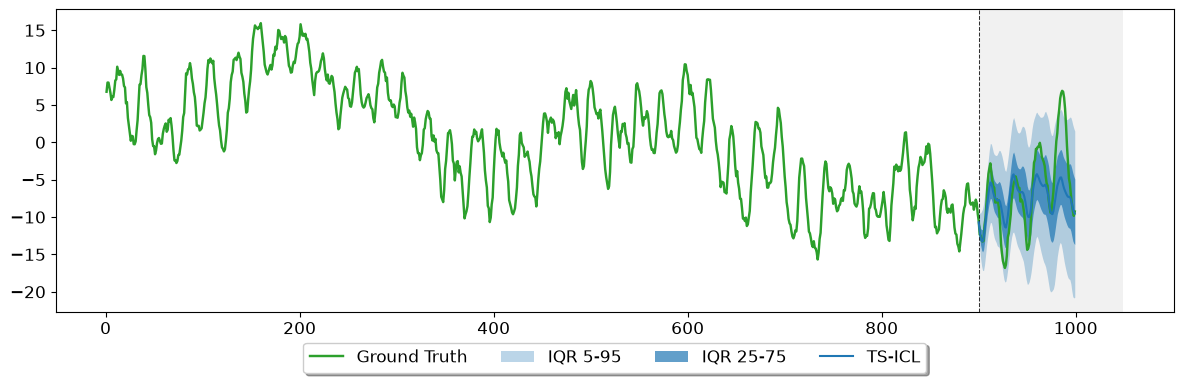

In [29]:
fig, ax = plot_sample_forecast(
    quantiles       = pred_quantiles,         # [horizon, Q]
    y_true          = signal[-horizon:],
    y_ctx           = signal[:context],
    quantile_levels = quantile_levels,
    plot_iqr        = True,
    model_name      = "TS-ICL",
    iqr_bands       = ((0.05, 0.95), (0.25, 0.75))
)
plt.show()
plt.close()

<a id="univariate-partially-forecasting"></a>

### 1.2 Forecasting with a Partially Observed Look-back

Patch-based foundation models divide the context into fixed-size windows and cannot handle `NaN` values natively. TS-ICL’s time-indexed encoder processes only the observed (timestamp, value) pairs, making it inherently robust to missing history — a common occurrence due to sensor outages, transmission failures, or irregular sampling.

Here we randomly drop 30% of the look-back observations and show that forecasting quality degrades only marginally.

Missing in look-back: 275 / 900  (31%)


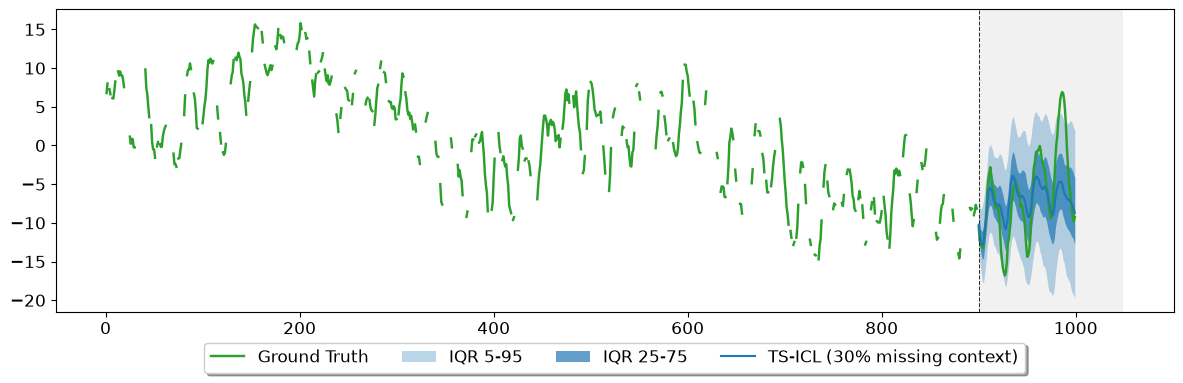

In [30]:
# ── Create partially observed look-back ───────────────────────────────
rng_partial = np.random.default_rng(7)
ctx_partial = signal[:context].copy()
mask_ctx    = rng_partial.random(context) < 0.30
ctx_partial[mask_ctx] = np.nan
print(f"Missing in look-back: {mask_ctx.sum()} / {context}  ({100 * mask_ctx.mean():.0f}%)")

_, batch_q_partial = model.forecast(
    inputs            = ctx_partial,
    prediction_length = horizon,
    context_length    = context,
    batch_size        = 1,
    device            = device,
    quantile_levels   = quantile_levels,
    denormalize       = True
)
pred_partial_ctx = batch_q_partial.squeeze().cpu().numpy()   # [horizon, Q]

fig, ax = plot_sample_forecast(
    quantiles       = pred_partial_ctx,
    y_true          = signal[-horizon:],
    y_ctx           = ctx_partial,
    quantile_levels = quantile_levels,
    plot_iqr        = True,
    model_name      = "TS-ICL (30% missing context)",
    iqr_bands       = ((0.05, 0.95), (0.25, 0.75))
)
plt.show()
plt.close()

TS-ICL’s time-indexed design is robust to history degradation. Patch-based models require contiguous, fully-observed context windows and would need imputation as a pre-processing step — introducing an additional source of error.

<a id="covariate-forecasting"></a>

---
### 1.3 Forecasting with a Known Covariate

#### Why covariates matter

Many real-world time series are driven by an exogenous process that can be observed or forecast independently. TS-ICL integrates any number of such **covariates** without retraining, using cross-attention in the Channel Mixer to selectively incorporate their information.

Examples evaluated in the paper (French transmission-system operator data):

| Target | Covariate | Physical coupling |
|---|---|---|
| Wind-farm power output | Wind speed | Power ∝ wind³ |
| Solar PV production | Surface solar irradiance | Power ∝ irradiance |
| National electricity load | Mean outdoor temperature | Temperature significantly impacts electricity demand levels |

In each case the covariate is **known over the forecast horizon** — wind and irradiance forecasts are available days ahead, temperature is closely tied to calendar season.

#### Our example

Our `signal` is the sum of `daily_pattern` and `weekly_pattern`. When forecasting a 100-point horizon, the model must extrapolate the weekly phase beyond what it has seen in the context. Supplying `weekly_pattern` as a **fully-observed covariate** — over the full 1 000 timesteps including the horizon — gives the model an exact anchor for the low-frequency component, so it can focus on predicting the daily fluctuations.

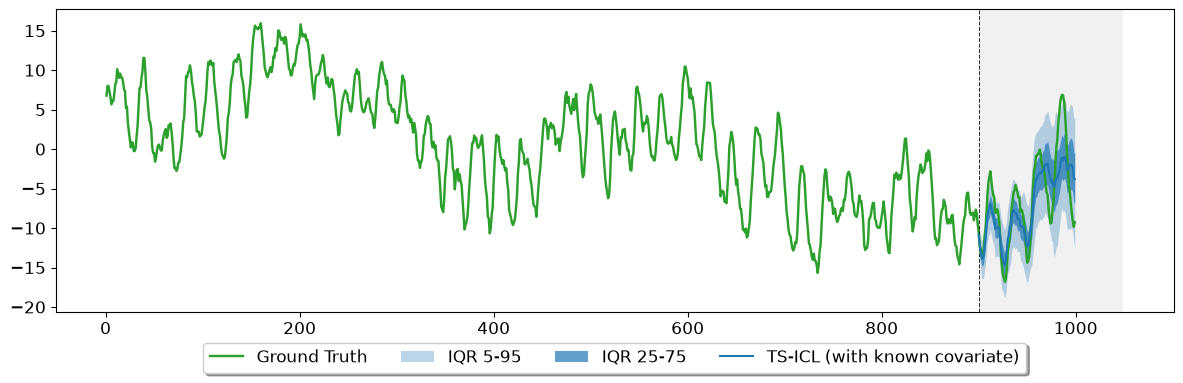

In [31]:
# ── Inference WITH covariate ───────────────────────────────────────────────
# weekly_pattern spans T=1000 timesteps (context + horizon).
# The model uses it both to anchor the look-back and to sharpen the forecast.
_, batch_q_covar = model.forecast(
    inputs            = signal[:context],
    prediction_length = horizon,
    context_length    = context,
    batch_size        = 1,
    covars            = weekly_pattern,   # shape [T] covers context + horizon
    device            = device,
    quantile_levels   = quantile_levels,
    denormalize       = True,
    
)
pred_covar = batch_q_covar.cpu().numpy()   # [horizon, Q]

fig, ax = plot_sample_forecast(
    quantiles       = pred_covar,
    y_true          = signal[-horizon:],
    y_ctx           = signal[:context],
    quantile_levels = quantile_levels,
    plot_iqr        = True,
    model_name      = "TS-ICL (with known covariate)",
    iqr_bands       = ((0.05, 0.95), (0.25, 0.75))
)
plt.show()
plt.close()

<a id="past-covariate-forecasting"></a>

---
#### 1.4. Inference with past-only covariate

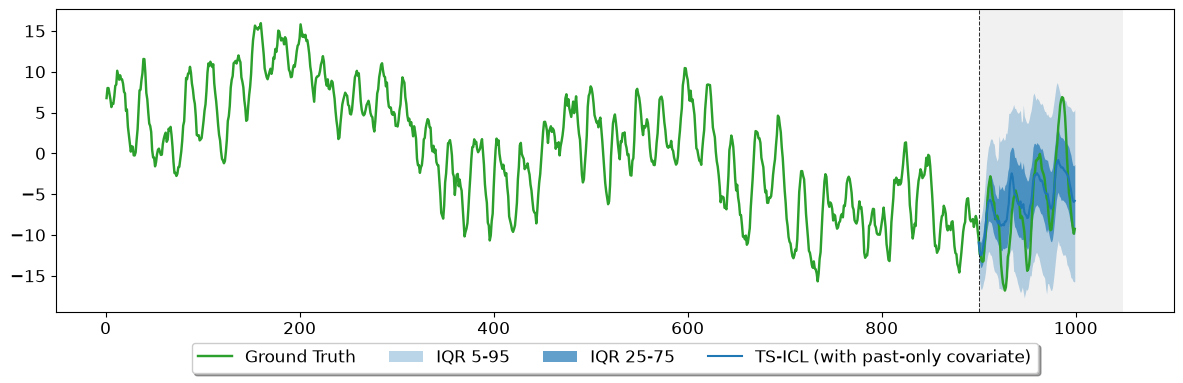

In [32]:
# ── Inference WITH past-only covariate ───────────────────────────────────────────────
# weekly_pattern spans L=900 timesteps (context).
_, batch_q_covar = model.forecast(
    inputs               = signal[:context],
    prediction_length    = horizon,
    context_length       = context,
    batch_size           = 1,
    covars               = weekly_pattern[:context],   # shape [L] covers context
    device               = device,
    quantile_levels      = quantile_levels,
    allow_covar_forecast = True,                       # allow covariate forecast
    denormalize          = True,
    
)
pred_covar_past = batch_q_covar.cpu().numpy()   # [horizon, Q]

fig, ax = plot_sample_forecast(
    quantiles       = pred_covar_past,
    y_true          = signal[-horizon:],
    y_ctx           = signal[:context],
    quantile_levels = quantile_levels,
    plot_iqr        = True,
    model_name      = "TS-ICL (with past-only covariate)",
    iqr_bands       = ((0.05, 0.95), (0.25, 0.75))
)
plt.show()
plt.close()

### Quantitative comparison

The table below evaluates predictions **at the horizon positions** and measures two things:
- **MAE** (↓) — accuracy of the median forecast
- **Mean WQL** (↓) — Weighted Quantile Loss across all quantile levels, assessing both calibration and sharpness

In [33]:
q_idx = {q: i for i, q in enumerate(quantile_levels)}

y_true_missing = signal[-horizon:]

def horizon_mae(preds):
    return np.mean(np.abs(y_true_missing - preds[:, q_idx[0.5]]))

def horizon_wql(preds):
    """
    Computes the Mean Weighted Quantile Loss (WQL) across all quantile levels.
    This version is normalized by the absolute sum of y_true (GluonTS/Amazon Forecast standard).
    At quantile 0.5, it is mathematically equivalent to WAPE.
    """
    wql_per_quantile = []
    sum_y_true = np.sum(np.abs(y_true_missing))
    
    for q in quantile_levels:
        y_pred = preds[:, q_idx[q]]
        error = y_true_missing - y_pred
        
        # Compute Pinball Loss for the specific quantile q
        pinball_loss = np.maximum(q * error, (q - 1) * error)
        
        # Compute WQL for this specific quantile
        wql_q = 2 * np.sum(pinball_loss) / sum_y_true
        wql_per_quantile.append(wql_q)
        
    # Return the average WQL across all quantiles
    return np.mean(wql_per_quantile)

In [34]:
mae_no      = horizon_mae(pred_quantiles)
mae_co      = horizon_mae(pred_covar)
mae_co_past = horizon_mae(pred_covar_past)

wql_no      = horizon_wql(pred_quantiles)
wql_co      = horizon_wql(pred_covar)
wql_co_past = horizon_wql(pred_covar_past)

col1_w, col2_w, col3_w, col4_w = 20, 16, 18, 22

header = f"{'Metric':<{col1_w}} {'No covariate':>{col2_w}} {'With covariate':>{col3_w}} {'   With past-only covariate   ':>{col4_w}}"
print(header)
print("─" * (len(header) + 12)) 

# MAE
check_co = '✅' if mae_co < mae_no else '⚠️'
check_past = '✅' if mae_co_past < mae_no else '⚠️'
print(f"{'MAE (↓)':<{col1_w}} {mae_no:>{col2_w}.4f} {mae_co:>{col3_w}.4f} {check_co} {mae_co_past:>{col4_w}.4f} {check_past}")

# Mean WQL
check_wql_co = '✅' if wql_co < wql_no else '⚠️'
check_wql_past = '✅' if wql_co_past < wql_no else '⚠️'
print(f"{'Mean WQL (↓)':<{col1_w}} {wql_no:>{col2_w}.4f} {wql_co:>{col3_w}.4f} {check_wql_co} {wql_co_past:>{col4_w}.4f} {check_wql_past}")

Metric                   No covariate     With covariate    With past-only covariate   
───────────────────────────────────────────────────────────────────────────────────────────────────
MAE (↓)                        3.0551             2.7468 ✅                 2.8529 ✅
Mean WQL (↓)                   0.2516             0.1950 ✅                 0.2518 ⚠️


#### What the numbers show

The results demonstrate how the model adjusts to covariate availability:

* **Full-horizon (`With known covariate`):** Knowing the weekly phase across both past and future yields the best results, significantly dropping both **MAE** and **Mean WQL** by removing long-range uncertainty.
* **Past-only (`With past-only covar`):** Providing covariate historical context only is still beneficial—it sharpens the median trajectory (**lower MAE**), though the lack of future visibility leaves the uncertainty boundaries (**Mean WQL**) on par with TS-ICL without covariate.

#### A note on covariate availability

TS-ICL accommodates flexible covariate patterns. The `covars` tensor can span:
* **The full window** (context + horizon) — The most informative case, yielding optimal metrics.
* **Context only** (covariate unknown during the horizon) — Useful for anchoring the historical look-back.
* **A subset of timesteps** — Pass `NaN` for unobserved positions; the model handles them.

To pass **multiple covariates**, stack them along the last dimension:

```python
# Two covariates: shape [T, 2]
covar_2 = np.random.randn(T)
covars  = np.stack([weekly_pattern, covar_2], axis=-1)

<a id="output-format"></a>

---
## Part 2 — Understanding the Output Format

Unlike imputation, which returns predictions at all T timesteps, **forecasting returns predictions only at the `prediction_length` future positions**. The context is not re-predicted.

### Quantile indexing and calibration check

In [35]:
# ── Inspect output from section 1.1 ───────────────────────────────────────────
print(f"Shape: {pred_quantiles.shape}  →  {pred_quantiles.shape[0]} timesteps × {pred_quantiles.shape[1]} quantiles")

print("\nQuantile levels and column indices:")
for q, idx in q_idx.items():
    print(f"  [{idx:2d}]  Q{int(q*100):02d}  →  first forecast step (t={context}): {pred_quantiles[0, idx]:.3f}")

Shape: (100, 13)  →  100 timesteps × 13 quantiles

Quantile levels and column indices:
  [ 0]  Q01  →  first forecast step (t=900): -12.585
  [ 1]  Q05  →  first forecast step (t=900): -12.359
  [ 2]  Q10  →  first forecast step (t=900): -11.923
  [ 3]  Q20  →  first forecast step (t=900): -11.440
  [ 4]  Q25  →  first forecast step (t=900): -11.270
  [ 5]  Q30  →  first forecast step (t=900): -11.191
  [ 6]  Q50  →  first forecast step (t=900): -10.704
  [ 7]  Q70  →  first forecast step (t=900): -10.366
  [ 8]  Q75  →  first forecast step (t=900): -10.247
  [ 9]  Q80  →  first forecast step (t=900): -10.060
  [10]  Q90  →  first forecast step (t=900): -9.516
  [11]  Q95  →  first forecast step (t=900): -9.238
  [12]  Q99  →  first forecast step (t=900): -8.021


In [36]:
# ── Calibration check at the forecast horizon ──────────────────────────────────
y_true = signal[-horizon:]

mae = np.mean(np.abs(y_true - pred_quantiles[:, q_idx[0.5]]))

# Empirical coverage should match the nominal quantile level for a calibrated model
cov_80 = np.mean(
    (y_true >= pred_quantiles[:, q_idx[0.10]]) &
    (y_true <= pred_quantiles[:, q_idx[0.90]])
)
cov_50 = np.mean(
    (y_true >= pred_quantiles[:, q_idx[0.25]]) &
    (y_true <= pred_quantiles[:, q_idx[0.75]])
)

print(f"MAE at forecast horizon   : {mae:.4f}")
print(f"80% interval coverage     : {100 * cov_80:.1f}%   (nominal: 80%)")
print(f"50% interval coverage     : {100 * cov_50:.1f}%   (nominal: 50%)")
print()
print("Coverage close to the nominal level indicates well-calibrated predictions.")

MAE at forecast horizon   : 3.0551
80% interval coverage     : 89.0%   (nominal: 80%)
50% interval coverage     : 59.0%   (nominal: 50%)

Coverage close to the nominal level indicates well-calibrated predictions.


<a id="batch-processing"></a>

---
## Part 3 — Batch Processing

Stack multiple time series into a single `[N, C, 1]` tensor to forecast them in one call. The `batch_size` argument controls how many series pass through the model per forward pass — reduce it if you run out of GPU memory.

> **Variable-length series:** if your series have different context lengths, pass a *list* of `[C_i, 1]` tensors instead of a stacked tensor. The model handles variable lengths natively.

In [37]:
N         = 8
rng_batch = np.random.default_rng(99)
phases    = rng_batch.uniform(0, 2 * np.pi, size=N)
t_batch   = np.arange(T, dtype=float)

batch_signals = np.stack([
    2.0 * np.sin(2 * np.pi * t_batch / 24 + phases[i])
    + 0.4 * np.sin(2 * np.pi * t_batch / 168)
    for i in range(N)
], axis=0)   # [N, T]

batch_ctx = batch_signals[:, :context]   # [N, context]

# ── Batch inference ─────────────────────────────────────────────────────
batch_p_all, batch_q_all = model.forecast(
    inputs            = torch.tensor(batch_ctx, dtype=torch.float32).unsqueeze(-1),  # [N, context, 1]
    prediction_length = horizon,
    context_length    = context,
    batch_size        = 8,           # process up to 8 series per forward pass
    device            = device,
    quantile_levels   = quantile_levels,
    denormalize       = True
)
preds_all_q = batch_q_all.squeeze(1).cpu().numpy()   # [N, horizon, Q]
print(f"Batch output shape: {preds_all_q.shape}  →  {N} series × {horizon} timesteps × {len(quantile_levels)} quantiles")

Batch output shape: (8, 100, 13)  →  8 series × 100 timesteps × 13 quantiles


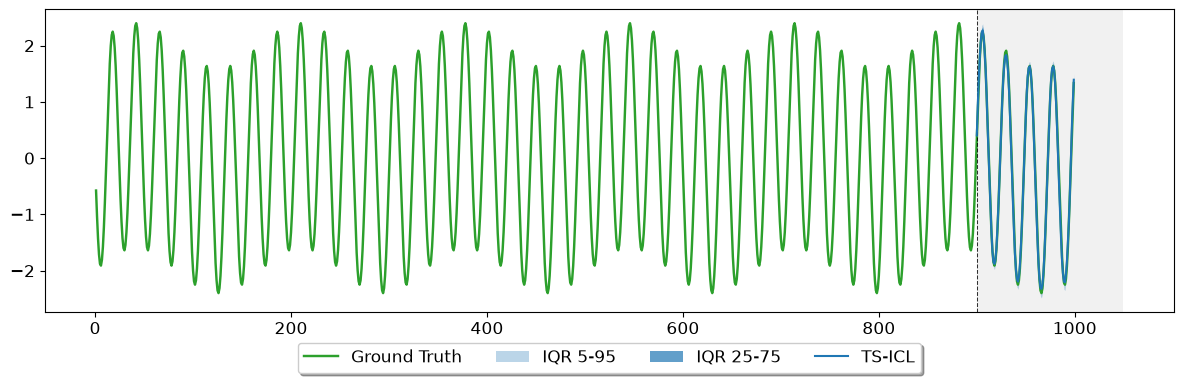

In [38]:
# ── Plot the first series in the batch ─────────────────────────────────────────
s = 0
fig, ax = plot_sample_forecast(
    quantiles       = preds_all_q[s],               # [horizon, Q]
    y_true          = batch_signals[s, -horizon:],
    y_ctx           = batch_signals[s, :context],
    quantile_levels = quantile_levels,
    plot_iqr        = True,
    model_name      = "TS-ICL",
    iqr_bands       = ((0.05, 0.95), (0.25, 0.75))
)
plt.show()
plt.close()

<a id="tips-practices"></a>

---
## Part 4 - Tips & Best Practices

### Details on `.forecast` method’s arguments

The `.forecast` method predicts future values from a look-back window. Below is the structured breakdown of its configuration parameters, input data structures, and expected outputs.

---

#### Configuration Parameters

| Parameter | Type | Default | Description |
| --- | --- | --- | --- |
| **`prediction_length`** | `int` | required | Number of future timesteps to forecast. |
| **`context_length`** | `int` | `None` | Length of the look-back window. Inferred from input shape if not provided. |
| **`batch_size`** | `int` | `64` | The batch size used during the inference run. |
| **`quantile_levels`** | `List[float]` | `[0.1, ..., 0.9]` | Quantile levels to compute. Must be a subset of `[0.01, 0.02, ..., 0.99]`. |
| **`device`** | `torch.device` | `cpu` | Target device for execution (e.g., `'cuda'`, `'cpu'`). |
| **`denormalize`** | `bool` | `True` | Whether to return values denormalized in original data space. |
| **`point_estimator`** | `Literal['mean', 'median']` | `'mean'` | Sets the pointwise estimator either as the average of all quantiles (`'mean'`) or as the 0.5 quantile (`'median'`). |
| **`squeeze_output`** | `bool` | `False` | If `True`, removes all unit dimensions (`1`) from the final output tensors. |
| **`allow_auto_complete`** | `bool` | `False` | Allow imputation of both the lookback window and/or the missing covariates, if any, and use the reconstructed values as extended context for the target time series. |
| **`allow_covar_forecast`** | `bool` | `False` | Allow forecasting of past-only covariates and use forecasted values as extended context for the target time series. |
---

#### Input Data Structures

#### `inputs`

The look-back context from which to forecast. `NaN` values within the context are handled natively — no prior imputation pre-processing is required. Accepts the following formats and shapes:

* **Multi-dimensional array-like (`torch.Tensor` or `np.ndarray`):**
  * **1D:** `(context_length,)`
  * **2D:** `(batch, context_length)`
  * **3D:** `(batch, context_length, num_variates)` where `num_variates >= 1`.

* **List of array-likes (`List[Tensor | ndarray]`):** Each element can be 1D or 2D.
  * **1D:** `(context_length,)`
  * **2D:** `(context_length, num_variates)`
  * *Note: `context_length` can vary across list elements, but `num_variates` must remain identical.*

* **pandas DataFrame (`pd.DataFrame`):** Must be 2-dimensional with shape `(batch, context_length)`.

---

#### `covars` *(Optional)*

Exogenous features to sharpen the forecast. For maximum benefit, covariates should ideally **extend over both the context and the forecast horizon**. However, full coverage is not mandatory; you can provide past-only covariates as well as sparse covariates containing `NaN`s.

The expected `covars_length` can be equal to `context_length + prediction_length`, `context_length` only, or `context_length` filled with `NaN`s for the future horizon.

* **Multi-dimensional array-like (`torch.Tensor` or `np.ndarray`):**
  * **1D:** `(covars_length,)` *(Single covariate)*
  * **2D:** `(batch, covars_length)` *(Single covariate)*
  * **3D:** `(batch, covars_length, num_covariates)` where `num_covariates >= 1`.
  * **4D:** `(batch, num_covariates, covars_length, 1)`

* **List of array-likes (`List[Tensor | ndarray]`):** Each element can be multi-dimensional:
  * **1D:** `(covars_length,)` *(Single covariate)*
  * **2D:** `(covars_length, num_covariates)` where `num_covariates >= 1`.
  * **3D:** `(covars_length, num_covariates, 1)`

#### Returns

The method returns a tuple `(point_predictions, quantile_predictions)`. Both cover only the **forecast horizon**, not the context:

1. **`point_predictions`** — Shape `(batch, num_variates, prediction_length, 1)`
2. **`quantile_predictions`** — Shape `(batch, num_variates, prediction_length, len(quantile_levels))`

### Memory & throughput
- **`batch_size`:** reduce to 1–4 if you run out of GPU memory.
- **Maximum context:** the forecasting checkpoint supports up to **T = 4 096** context timesteps.
- **Inference speed:** ~15.4 ms per window on an H100 GPU.

---

This notebook only scratches the surface — TS-ICL’s forecasting capabilities go well beyond what’s shown here. The best way to discover them is to read the [documentation](https://edf-lab.github.io/ts-icl/autoapi/tsicl/pipeline/index.html) and experiment with your own data!